# Structure and deterioration of semantic memory
<p>Semantic memory is our knowledge of concepts, facts, and word meanings. It allows information acquired in different forms to contribute to a coherent understanding of an object. For example, we can recognize a cup by its appearance, refer to it by the word “cup,” and know that it can hold water for drinking. Its appearance, name, and use are connected in our understanding of the same object. Research on semantic memory helps us understand how knowledge is organized in the brain.</p>
<p>Semantic dementia provides a way to investigate how this knowledge is organized. As the disease progresses, knowledge becomes less specific: a person may recognize that an object is an animal while no longer knowing which animal it is. Drawings may retain features shared by many animals while losing the details that distinguish one from another. The loss is gradual and structured.</p>
<p>Rogers and colleagues (2004) asked whether these patterns could arise from damage to a shared system that learns associations between visual features, names, and verbal descriptions. Knowledge is distributed across connections. Objects that share features come to evoke related patterns of activity, without assigning a separate hidden unit to each concept.</p>
<p>To examine this account, the authors implemented the shared system as a recurrent neural network. The network first learns to recover an object's properties from a partial cue. Connections are then removed, and the same damaged network is tested on naming, sorting, word–picture matching, and drawing.</p>
<p>The model represents names, visual features, and verbal descriptions in separate groups of units, all connected to a shared layer of 64 hidden units. Connections run in both directions between the visible and hidden layers, and hidden units also connect to one another. The model learns these connection weights from associations among the three forms of information.</p>

## Tutorial objectives

This tutorial connects three questions: how information about an object is represented, how a partial cue evokes the rest of that information, and how deleting connections changes the response.

The notebook contains the article, executable PyTorch examples, and interactive comparisons. The teaching sequence follows the pattern of [Neuromatch tutorials](https://compneuro.neuromatch.io/tutorials/W1D5_DeepLearning/student/W1D5_Tutorial1.html): an explanation, a short calculation, and an experiment. It is an independent paper reproduction, not an official Neuromatch tutorial.


## Setup

The setup cell locates a local checkout or downloads the public repository in Colab. Dependencies are installed only when missing. All default cells run on a CPU; a full retraining run is optional.

In [1]:
# @title Environment and repository
import importlib.util, subprocess, sys
from pathlib import Path
packages = {'numpy':'numpy', 'torch':'torch', 'matplotlib':'matplotlib',
            'pandas':'pandas', 'ipywidgets':'ipywidgets', 'PIL':'pillow'}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'notebooks/rogers2004/rogers_model.py').is_file()), None)
if ROOT is None:
    ROOT = Path.cwd()/'papers'
    if not (ROOT/'notebooks/rogers2004/rogers_model.py').is_file():
        if ROOT.exists():
            raise RuntimeError('The papers directory exists but is not this repository.')
        subprocess.check_call(['git', 'clone', '--depth', '1',
                              'https://github.com/h4ch1m1/complementary-learning-systems.git', str(ROOT)])
sys.path.insert(0, str(ROOT/'notebooks/rogers2004'))
import json, copy
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, SVG, Image, Markdown, clear_output
from PIL import Image as PILImage
import rogers_model as m
from tune_model import audit
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
torch.set_num_threads(1)
torch.manual_seed(12345)
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False})
model, env = m.load(ROOT/'outputs/rogers2004/tuning/adam')
model.eval()
labels = list(map(str, env['item_labels']))
photo_sources = json.loads((ROOT/'assets/rogers_objects/sources.json').read_text(encoding='utf8'))
targets = torch.from_numpy(env['targets'])
POOLS = {'Name':slice(0,40), 'Verbal description':slice(40,152), 'Visual features':slice(152,216)}
print(f'{len(labels)} objects; {targets.shape[1]} visible units; {m.HIDDEN} semantic units.')

48 objects; 216 visible units; 64 semantic units.


D:\复现用文件夹\cls_development_backup_2026-09-19\local_environment\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# @title Plotting helpers
import re

def reference_image(ax, item):
    key = re.sub(r'_\d+$', '', labels[item])
    src = photo_sources[key]['src']
    with PILImage.open(ROOT/'website'/src) as im:
        ax.imshow(im.copy())
    ax.axis('off')
    ax.set_title(labels[item])

def feature_grid(ax, values, title, vmax=1):
    values = np.asarray(values)
    columns = 16 if values.size == 112 else 8
    ax.imshow(values.reshape(-1, columns), cmap='Blues', vmin=0, vmax=vmax, interpolation='nearest')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

def cue_for(item, modality):
    cue = targets[item:item+1].clone()
    mask = torch.zeros_like(cue, dtype=torch.bool)
    mask[:, POOLS[modality]] = True
    return cue, mask

OBJECTS = [(label,i) for i,label in enumerate(labels)]
PHOTO_CREDITS = '\n'.join(f'- {v["title"]}: [source and attribution]({v["source"]})' for v in photo_sources.values())

## 1. Objects, features, and the shared representation

<p>The network learns 48 objects represented by names, visual features, and verbal descriptors.</p>

The following comparison uses the stored feature vectors. A shared active feature contributes to the intersection; a feature active in either object contributes to the union. Their ratio summarizes overlap.

In [3]:
def compare_objects(first=3, second=4, pool='Visual features'):
    av = env['targets'][first, POOLS[pool]]
    bv = env['targets'][second, POOLS[pool]]
    shared = int(np.logical_and(av,bv).sum())
    union = int(np.logical_or(av,bv).sum())
    fig, ax = plt.subplots(2,2,figsize=(8,5), gridspec_kw={'width_ratios':[1,2]})
    for row,item,values in [(0,first,av),(1,second,bv)]:
        reference_image(ax[row,0],item)
        feature_grid(ax[row,1],values,pool)
    plt.tight_layout(); plt.show()
    print(f'{shared} shared active features / {union} active in either object: {shared/max(union,1):.1%}')

widgets.interact(compare_objects,
    first=widgets.Dropdown(options=OBJECTS,value=3,description='First'),
    second=widgets.Dropdown(options=OBJECTS,value=4,description='Second'),
    pool=widgets.Dropdown(options=['Visual features','Verbal description'],description='Features'));

interactive(children=(Dropdown(description='First', index=3, options=(('bird_1', 0), ('bird_2', 1), ('bird_3',…

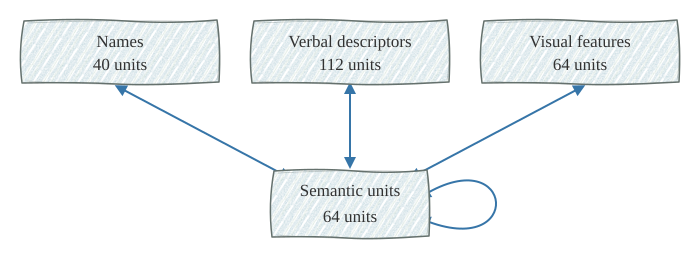

In [4]:
display(SVG('<svg viewBox="0 0 700 270" role="img" aria-labelledby="network-title network-desc">\n<title id="network-title">Three visible pools share 64 recurrent semantic units</title><desc id="network-desc">Names, verbal descriptors and visual features connect bidirectionally to semantic units. Semantic units also connect to each other.</desc>\n<defs>\n<marker id="arrow" viewBox="0 0 10 10" refX="5" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse"><path d="M0 0L10 5L0 10Z" fill="#3675a8"/></marker>\n<filter id="crayon-grain" x="-5%" y="-5%" width="110%" height="110%">\n<feTurbulence type="fractalNoise" baseFrequency=".65" numOctaves="3" seed="12" result="grain"/>\n<feColorMatrix in="grain" type="luminanceToAlpha" result="texture"/>\n<feComposite in="SourceGraphic" in2="texture" operator="in"/>\n</filter>\n<pattern id="crayon-hatching" width="19" height="19" patternUnits="userSpaceOnUse" patternTransform="rotate(32)">\n<path d="M2 -3 Q0 6 2 13 L1 23 M7 -3 Q9 8 7 23 M13 -3 Q11 10 14 23 M18 -3 L17 23" fill="none" stroke="#74a4b5" stroke-width="3.3" stroke-linecap="round" opacity=".43"/>\n<path d="M4 -3 L5 23 M11 -3 L10 23" stroke="#aec9b7" stroke-width="1.5" opacity=".5"/>\n</pattern>\n</defs>\n<g stroke="#3675a8" stroke-width="2" fill="none" marker-start="url(#arrow)" marker-end="url(#arrow)"><path d="M120 88L286 176"/><path d="M350 88V163"/><path d="M580 88L414 176"/><path d="M424 195C515 140 525 261 424 220"/></g>\n<g><path d="M24 21 Q80.0 18 126.0 21 T217 20 Q221 45.6 219 82 Q150.0 86 116.0 84 T22 83 Q18 52.0 24 21 Z" fill="#fff"/><path d="M24 21 Q80.0 18 126.0 21 T217 20 Q221 45.6 219 82 Q150.0 86 116.0 84 T22 83 Q18 52.0 24 21 Z" fill="url(#crayon-hatching)" filter="url(#crayon-grain)"/><path d="M24 21 Q80.0 18 126.0 21 T217 20 Q221 45.6 219 82 Q150.0 86 116.0 84 T22 83 Q18 52.0 24 21 Z" fill="none" stroke="#65716d" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/><path d="M28 23 Q124.0 19 215 22 M217 27 Q221 58.4 217 80 M211 82 Q120.0 87 27 81" fill="none" stroke="#65716d" stroke-width=".7" opacity=".38" stroke-linecap="round"/></g>\n<g><path d="M254 21 Q310.0 18 356.0 21 T447 20 Q451 45.6 449 82 Q380.0 86 346.0 84 T252 83 Q248 52.0 254 21 Z" fill="#fff"/><path d="M254 21 Q310.0 18 356.0 21 T447 20 Q451 45.6 449 82 Q380.0 86 346.0 84 T252 83 Q248 52.0 254 21 Z" fill="url(#crayon-hatching)" filter="url(#crayon-grain)"/><path d="M254 21 Q310.0 18 356.0 21 T447 20 Q451 45.6 449 82 Q380.0 86 346.0 84 T252 83 Q248 52.0 254 21 Z" fill="none" stroke="#65716d" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/><path d="M258 23 Q354.0 19 445 22 M447 27 Q451 58.4 447 80 M441 82 Q350.0 87 257 81" fill="none" stroke="#65716d" stroke-width=".7" opacity=".38" stroke-linecap="round"/></g>\n<g><path d="M484 21 Q540.0 18 586.0 21 T677 20 Q681 45.6 679 82 Q610.0 86 576.0 84 T482 83 Q478 52.0 484 21 Z" fill="#fff"/><path d="M484 21 Q540.0 18 586.0 21 T677 20 Q681 45.6 679 82 Q610.0 86 576.0 84 T482 83 Q478 52.0 484 21 Z" fill="url(#crayon-hatching)" filter="url(#crayon-grain)"/><path d="M484 21 Q540.0 18 586.0 21 T677 20 Q681 45.6 679 82 Q610.0 86 576.0 84 T482 83 Q478 52.0 484 21 Z" fill="none" stroke="#65716d" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/><path d="M488 23 Q584.0 19 675 22 M677 27 Q681 58.4 677 80 M671 82 Q580.0 87 487 81" fill="none" stroke="#65716d" stroke-width=".7" opacity=".38" stroke-linecap="round"/></g>\n<g><path d="M274 171 Q318.0 168 354.8 171 T427 170 Q431 197.2 429 236 Q374.0 240 346.8 238 T272 237 Q268 204.0 274 171 Z" fill="#fff"/><path d="M274 171 Q318.0 168 354.8 171 T427 170 Q431 197.2 429 236 Q374.0 240 346.8 238 T272 237 Q268 204.0 274 171 Z" fill="url(#crayon-hatching)" filter="url(#crayon-grain)"/><path d="M274 171 Q318.0 168 354.8 171 T427 170 Q431 197.2 429 236 Q374.0 240 346.8 238 T272 237 Q268 204.0 274 171 Z" fill="none" stroke="#65716d" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/><path d="M278 173 Q353.2 169 425 172 M427 177 Q431 210.8 427 234 M421 236 Q350.0 241 277 235" fill="none" stroke="#65716d" stroke-width=".7" opacity=".38" stroke-linecap="round"/></g>\n<g text-anchor="middle" fill="#323232" font-size="17"><text x="120" y="47">Names</text><text x="120" y="70">40 units</text><text x="350" y="47">Verbal descriptors</text><text x="350" y="70">112 units</text><text x="580" y="47">Visual features</text><text x="580" y="70">64 units</text><text x="350" y="196">Semantic units</text><text x="350" y="222">64 units</text></g></svg>'))

The model connects all three forms of information to the same layer of 64 hidden units. Each arrow direction has independently learned weights.

Permitted connections: 31744


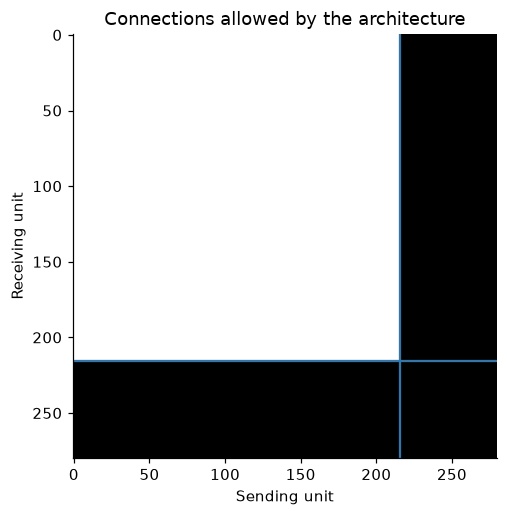

In [5]:
allowed = m.connection_mask()
assert allowed.shape == (280,280)
assert torch.count_nonzero(allowed[:216,:216]) == 0
print('Permitted connections:', int(allowed.sum()))
fig,ax = plt.subplots(figsize=(5,5))
ax.imshow(allowed, cmap='Greys', interpolation='nearest')
ax.set(xlabel='Sending unit',ylabel='Receiving unit',title='Connections allowed by the architecture')
ax.axvline(215.5,color='#3675a8');ax.axhline(215.5,color='#3675a8');plt.show()

**Checkpoint.** A semantic unit has no preset object label. An object is represented by the joint activity of all 64 units. The mask above permits visible–hidden and hidden–hidden connections, while excluding direct visible–visible connections.

## 2. Learning to complete a cue


<p>One input pool is initially held at its supplied values, a procedure called <em>clamping</em>. The cue is then released and activity continues circulating. The model compares its outputs with the target features and adjusts its connection weights using backpropagation through time to reduce the error.</p>
<div class="equation">u<sub>t+1</sub> = 0.75u<sub>t</sub> + 0.25(Wa<sub>t</sub> − 2), &nbsp; a<sub>t+1</sub> = σ(u<sub>t+1</sub>)</div>
<p>Here, <em>u</em> is net input, <em>a</em> is activity, <em>W</em> contains the connection weights, and σ is the logistic function. The update blends previous net input with input from connected units. The fixed bias of −2 favors low activity without excitation.</p>
<p>The original schedule uses 28 updates per trial: the input is clamped during the first three four-update intervals, and error is scored during the final two intervals. The paper reports 400 epochs. The initial reconstruction follows this schedule; our optimized extension changes the training objective and duration.</p>

### One recurrent update

The matrix uses rows for receiving units and columns for sending units. The calculation below shows the contribution from incoming activity, the retained net input, and the resulting activity for one hidden unit.

In [6]:
item = labels.index('chicken')
cue, mask = cue_for(item,'Name')
full_cue = torch.cat((cue,torch.zeros(1,64)),dim=1)
full_mask = torch.cat((mask,torch.zeros(1,64,dtype=torch.bool)),dim=1)
u0 = torch.where(full_mask,(full_cue*2-1)*15.9357739741644,torch.full_like(full_cue,-2.))
a0 = torch.where(full_mask,full_cue,torch.sigmoid(u0))
with torch.no_grad():
    incoming = a0 @ model.weight.T - 2
    u1 = .75*u0 + .25*incoming
    a1 = torch.sigmoid(u1)
    actual = m.dynamics(model.weight,cue,mask,1)[1]
assert torch.allclose(a1[:,216:],actual[:,216:])
unit = 216
pd.DataFrame({'quantity':['previous net input','weighted input minus bias','new net input','new activity'],
              'value':[u0[0,unit].item(),incoming[0,unit].item(),u1[0,unit].item(),a1[0,unit].item()]})

,quantity,value
0,previous net input,-2.000000
1,weighted input minus bias,-0.709394
2,new net input,-1.677349
3,new activity,0.157447


### Activity following a cue

We present a name, a verbal description, or a visual pattern and follow the network through successive updates. The input is fixed in states 0–11 and released at state 12. The animation uses the actual recurrent computation. Later displayed frames are farther apart in simulation time.

In [7]:
ticks = list(range(29))+[32,40,56,80,120,200,400]
trace_cache = {}
def retrieval(item=3, modality='Name', frame=0):
    key = (item,modality)
    if key not in trace_cache:
        cue,mask = cue_for(item,modality)
        with torch.no_grad():
            trace_cache[key] = m.dynamics(model.weight,cue,mask,400)[:,0].numpy()
    activity = trace_cache[key][ticks[frame]]
    fig = plt.figure(figsize=(10,5))
    gs = fig.add_gridspec(2,3,width_ratios=[.7,1,1])
    reference_image(fig.add_subplot(gs[:,0]),item)
    for j,(name,sl) in enumerate([('Names',slice(0,40)),('Verbal descriptors',slice(40,152)),
                                  ('Visual features',slice(152,216)),('Semantic units',slice(216,280))]):
        ax=fig.add_subplot(gs[j//2,1+j%2]);feature_grid(ax,activity[sl],name)
    plt.tight_layout();plt.show()
    winner = int(activity[:40].argmax())
    print('Name response:', str(env['names'][winner]) if activity[winner]>.5 else 'No response')

trace_item=widgets.Dropdown(options=OBJECTS,value=3,description='Object')
trace_cue=widgets.Dropdown(options=list(POOLS),description='Cue')
frame=widgets.IntSlider(min=0,max=len(ticks)-1,value=0,description='Progress',continuous_update=False)
play=widgets.Play(min=0,max=len(ticks)-1,interval=260)
widgets.jslink((play,'value'),(frame,'value'))
trace_output=widgets.interactive_output(retrieval,{'item':trace_item,'modality':trace_cue,'frame':frame})
display(widgets.VBox([widgets.HBox([trace_item,trace_cue]),widgets.HBox([play,frame]),trace_output]))

### Learning changes the connections

A short optimization experiment starts from a copy of the saved weights. The loss is calculated from the visible outputs at updates 21–56. Backpropagation through time assigns the error to connections that influenced those outputs. Adam then adjusts the permitted weights. This is the optimization extension, rather than the original 400-epoch training procedure.

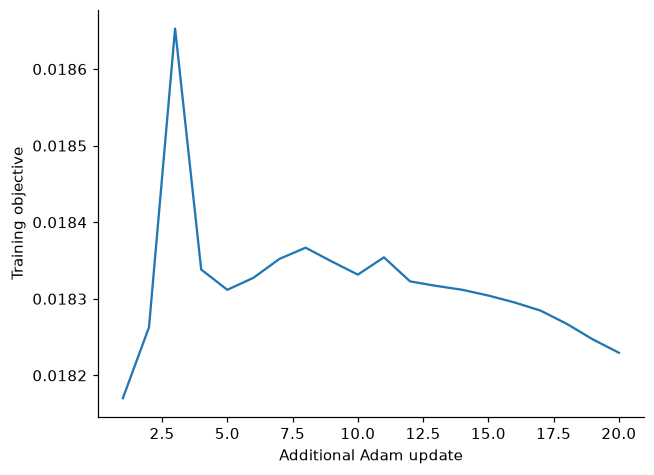

In [8]:
practice_model = copy.deepcopy(model)
training_targets = targets.repeat(3,1)
training_cues = training_targets.clone()
training_masks = torch.zeros_like(training_cues,dtype=torch.bool)
training_masks[:48,:40]=True
training_masks[48:96,40:152]=True
training_masks[96:,152:]=True
for i,name_id in enumerate(env['name_ids']):
    if name_id in m.GENERAL:
        eligible = np.isin(env['category'],m.GENERAL[name_id])
        training_targets[i,40:] = targets[eligible,40:].mean(0)
optimizer = torch.optim.Adam([practice_model.weight],lr=.001)
losses=[]
for step in range(20):
    optimizer.zero_grad()
    prediction=m.dynamics(practice_model.weight,training_cues,training_masks,56)[21:57,:,:216]
    loss=torch.nn.functional.binary_cross_entropy(prediction,training_targets.expand_as(prediction))
    loss=loss+1e-6*practice_model.weight.square().sum()/practice_model.allowed.sum()
    loss.backward()
    practice_model.weight.grad.mul_(practice_model.allowed)
    optimizer.step()
    with torch.no_grad():practice_model.weight.mul_(practice_model.allowed)
    losses.append(loss.item())
assert np.isfinite(losses).all()
plt.plot(range(1,21),losses);plt.xlabel('Additional Adam update');plt.ylabel('Training objective');plt.show()

### Optional original-schedule training

The default run uses saved weights so the whole lesson remains short. The optional cell below trains a fresh reconstruction for 400 epochs and writes its results to a separate directory. This run uses the original reconstructed environment, so it does not reproduce the optimized checkpoint above.

In [9]:
# @title Optional full training
RUN_FULL_TRAINING = False # @param {type:"boolean"}
if RUN_FULL_TRAINING:
    retrained_model,retrained_env=m.train(seed=12345,data_seed=2004,epochs=400,lr=.005,
                                         gradient_scale=1.,output=ROOT/'outputs/rogers2004/colab_training')
else:
    print('The lesson continues with the saved checkpoint.')

The lesson continues with the saved checkpoint.


## 3. Why recurrence matters

<p>At each update, a unit's activity contributes to the input received by connected units. Their updated activity then contributes to the next update, through connections among hidden units and through the two-way connections between hidden and visible units. The network can therefore continue updating after the external cue is removed. When these updates bring nearby activity patterns toward the same stable pattern, that pattern is called an <em>attractor</em>.</p>

**Checkpoint.** Releasing the cue removes the external constraint, not the recurrent connections. The next activity pattern still depends on the preceding activity. Convergence to a stable pattern is a property to check, rather than an automatic consequence of using recurrence.

## 4. Measured task performance

<table><thead><tr><th>Task</th><th>Cue and response</th><th>Measure</th></tr></thead><tbody>
<tr><td>Naming</td><td>Visual features → name</td><td>Strongest name above 0.5; otherwise no response.</td></tr>
<tr><td>Sorting</td><td>Name or picture → category predicates</td><td>Broad and specific categories; specific sorting is conditional on the true broad group.</td></tr>
<tr><td>Word–picture matching</td><td>Name and picture → hidden states</td><td>Whether the target is closer than the distractor in semantic space.</td></tr>
<tr><td>Drawing / delayed copying</td><td>Name or released visual cue → visual features</td><td>Missing and added features relative to the intact response.</td></tr>
</tbody></table>

### Feature loss in an individual damaged network

We compare intact and damaged visual responses to the same cue. A name cue corresponds to drawing from a name; a visual cue followed by its removal corresponds to delayed copying. Each damage sample removes a different set of connections. No retraining or rescaling follows damage.

In [10]:
with torch.no_grad():
    intact_outputs,intact_residual,intact_ticks=m.settled_probe(model,env)
damage_cache={}
def damaged_response(item=3, task='Drawing from a name', damage=.2, sample=1):
    modality='Name' if task=='Drawing from a name' else 'Visual features'
    key=(item,modality,damage,sample)
    if key not in damage_cache:
        generator=torch.Generator().manual_seed(2707+(sample-1)*100+round(damage*100))
        keep=torch.rand(model.weight.shape,generator=generator)>=damage
        cue,mask=cue_for(item,modality)
        with torch.no_grad():
            state,residual,end=m.settle(model.weight*keep,cue,mask)
        damage_cache[key]=(state[0].numpy(),float(residual[0]),end)
    state,residual,end=damage_cache[key]
    before=intact_outputs[0 if modality=='Name' else 2,item,152:216].numpy()>.5
    after=state[152:216]>.5
    changes=np.where(before & after,1,np.where(before & ~after,2,np.where(~before & after,3,0)))
    from matplotlib.colors import ListedColormap
    fig,ax=plt.subplots(1,3,figsize=(10,3),gridspec_kw={'width_ratios':[.8,1,1]})
    reference_image(ax[0],item);feature_grid(ax[1],before,'Intact response')
    ax[2].imshow(changes.reshape(8,8),vmin=0,vmax=3,cmap=ListedColormap(['#eef1f3','#3675a8','#d18538','#9470ad']))
    ax[2].set(title='Damaged: retained / omitted / added',xticks=[],yticks=[])
    plt.tight_layout();plt.show()
    winner=int(state[:40].argmax())
    print('Name:',str(env['names'][winner]) if state[winner]>.5 else 'No response',
          '| Omitted:',int((before & ~after).sum()),'| Added:',int((~before & after).sum()))
    if residual>=1e-5:print('Response unsettled at the update limit.')

widgets.interact(damaged_response,
 item=widgets.Dropdown(options=OBJECTS,value=3,description='Object'),
 task=widgets.Dropdown(options=['Drawing from a name','Delayed copying'],description='Task'),
 damage=widgets.SelectionSlider(options=[0.,.1,.2,.3,.4,.5],value=.2,description='Damage',continuous_update=False),
 sample=widgets.Dropdown(options=[1,2,3],description='Sample'));

interactive(children=(Dropdown(description='Object', index=3, options=(('bird_1', 0), ('bird_2', 1), ('bird_3'…

We compare performance at ten damage levels to examine how each task changes as more connections are removed. Nonzero levels average 50 masks applied to one trained network.

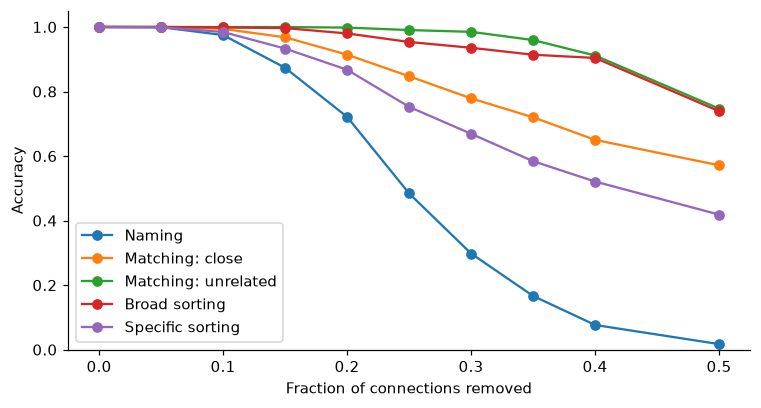

In [11]:
summary=json.loads((ROOT/'outputs/rogers2004/tuning/adam/summary.json').read_text())
metrics={'Naming':'naming/all/correct','Matching: close':'matching/close',
         'Matching: unrelated':'matching/unrelated',
         'Broad sorting':'sorting/picture/animal_artifact/general',
         'Specific sorting':'sorting/picture/animal_artifact/specific'}
levels=sorted(map(float,summary))
fig,ax=plt.subplots(figsize=(8,4))
for label,key in metrics.items():
    ax.plot(levels,[summary[str(level)][key]['mean'] for level in levels],marker='o',label=label)
ax.set(xlabel='Fraction of connections removed',ylabel='Accuracy',ylim=(0,1.05));ax.legend();plt.show()

The saved aggregate results can also be recalculated with the evaluator. The optional cell uses fresh masks from the same documented seed and leaves the supplied results intact.

In [12]:
# @title Optional full lesion evaluation
RUN_FULL_EVALUATION=False # @param {type:"boolean"}
if RUN_FULL_EVALUATION:
    recomputed=m.evaluate(model,env,ROOT/'outputs/rogers2004/colab_evaluation',trials=50,lesion_seed=1707)
else:
    print('The aggregate figure uses the saved 50-mask evaluation.')

The aggregate figure uses the saved 50-mask evaluation.


## 5. Structured errors

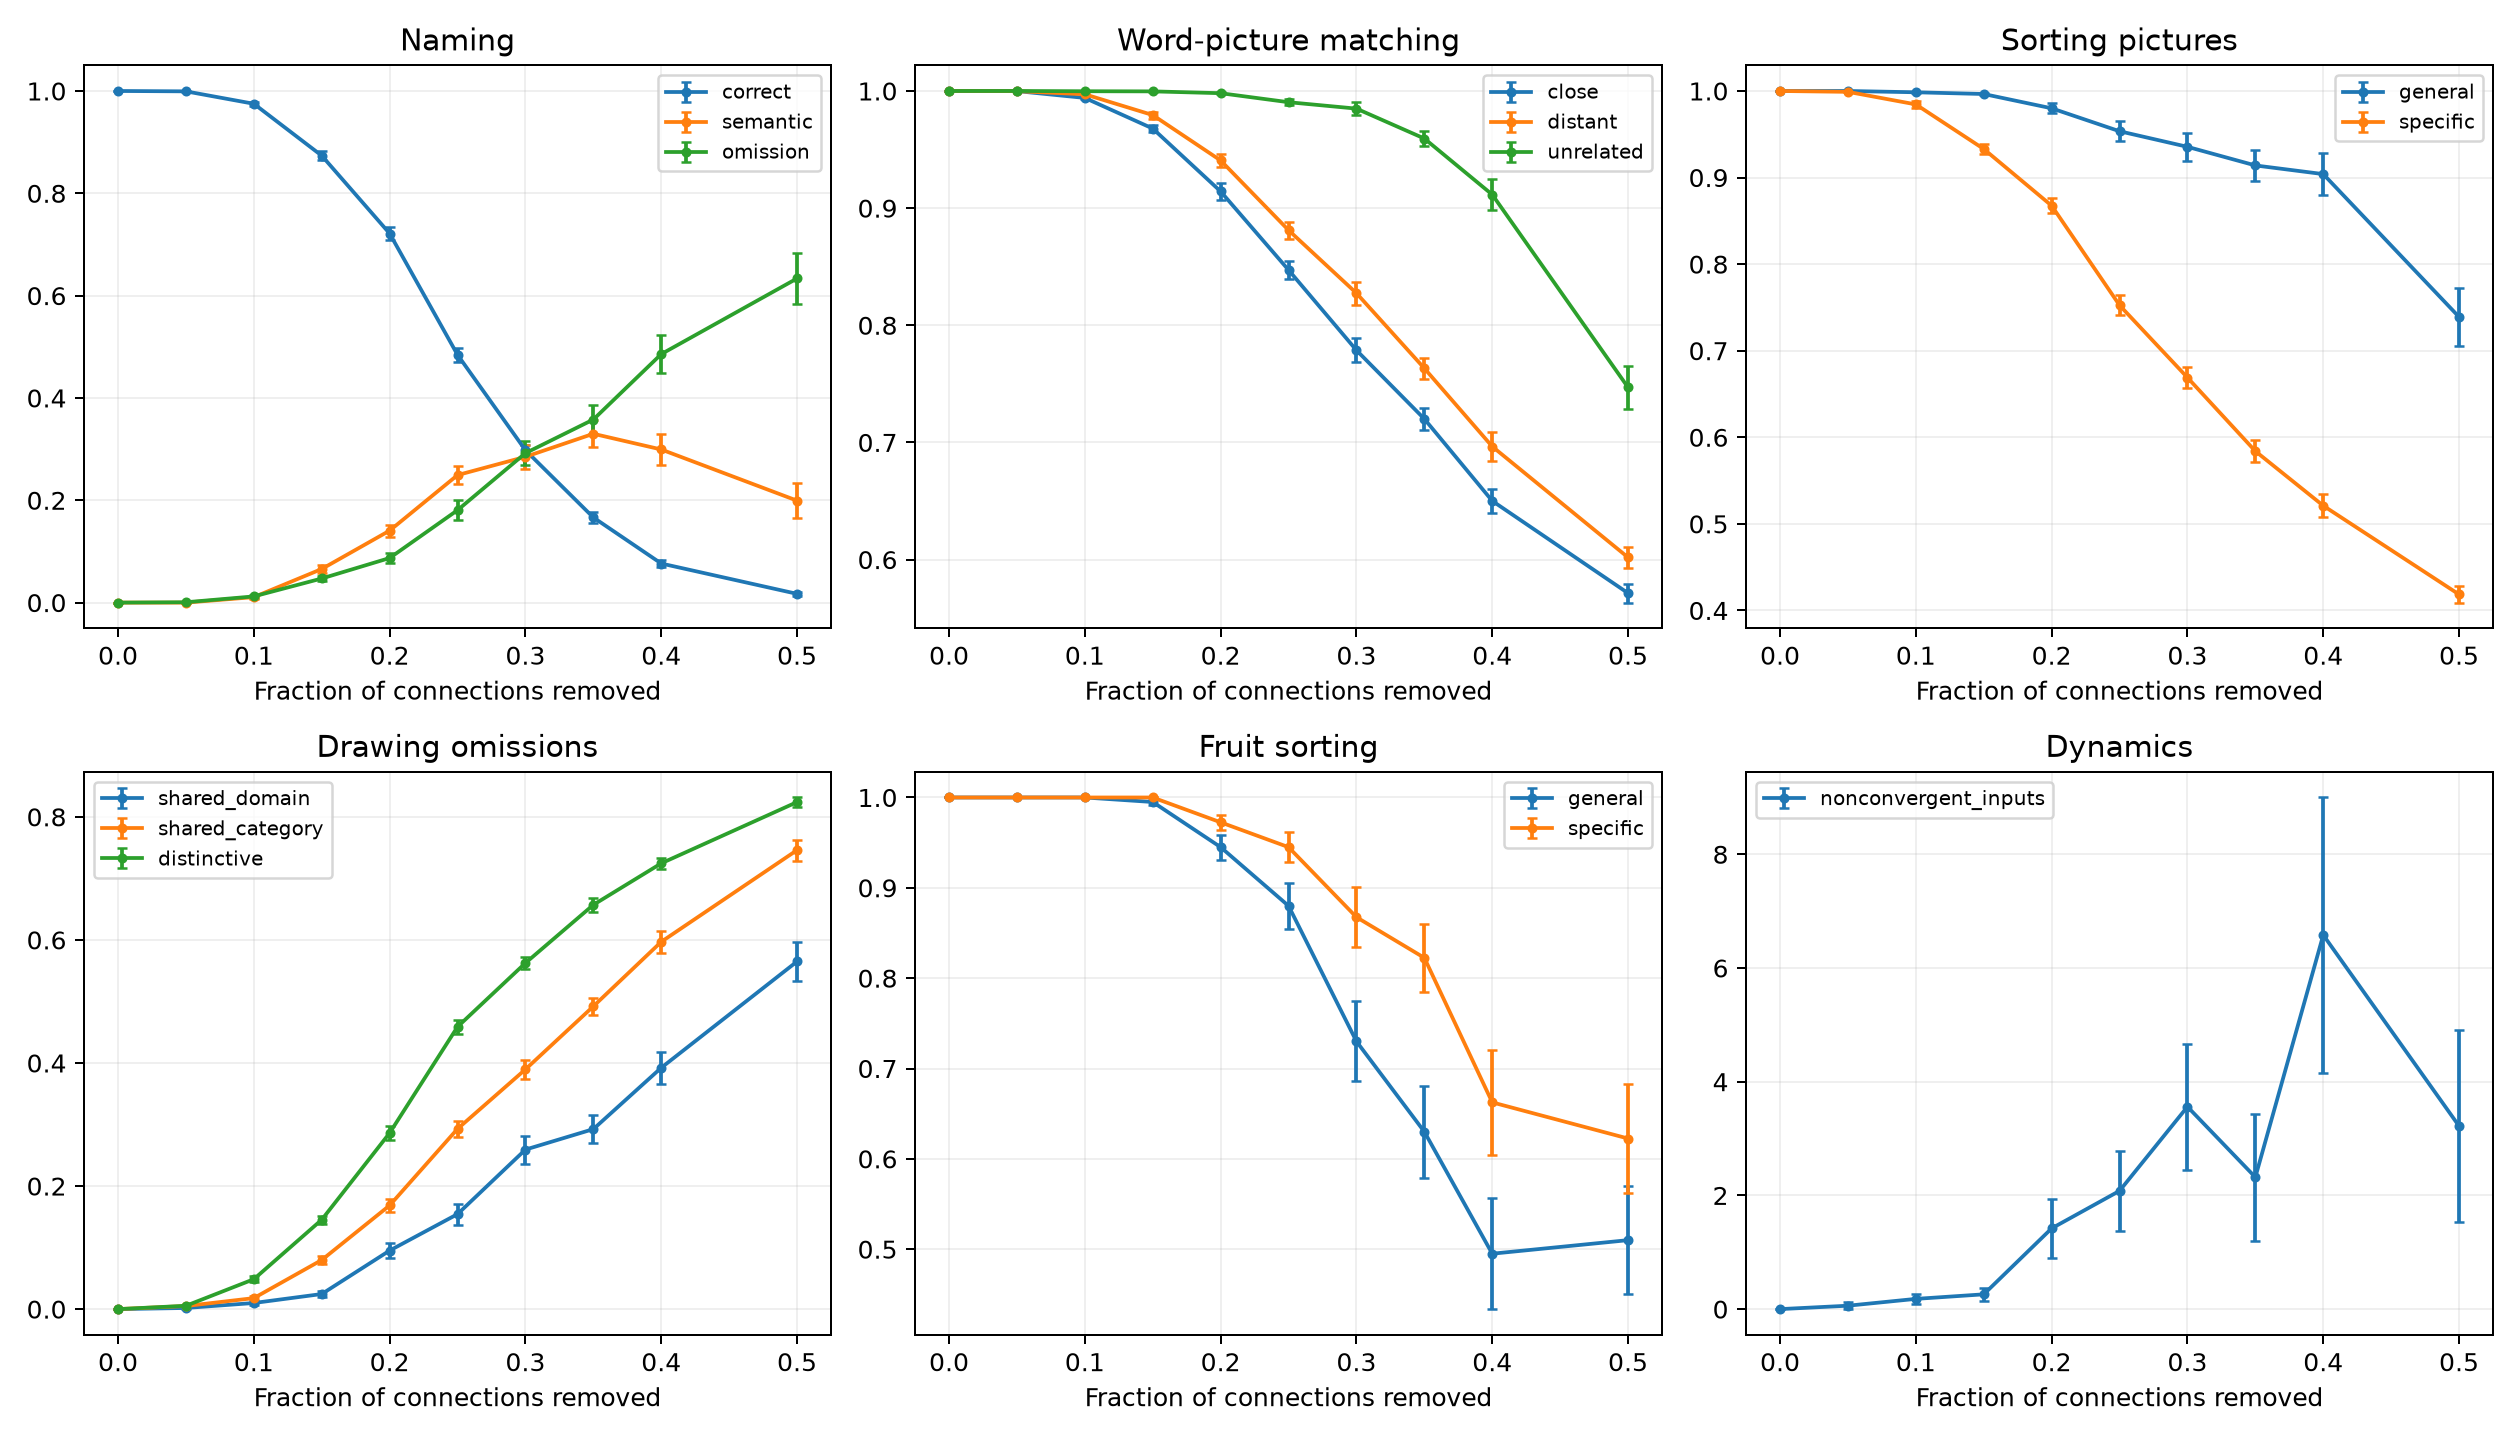

<p>Matching is harder with a nearby-category distractor than an unrelated one. Broad sorting generally survives longer than specific sorting. In drawing, distinctive properties disappear more readily than domain-shared properties. These trends are consistent with damage reducing access to fine distinctions between related concepts.</p>

<p>Fruits provide a demanding comparison: their visual properties overlap with artifacts, while verbal descriptions distinguish them. In this run, specific fruit sorting outlasts broad sorting, reversing the usual ordering.</p>

<table><thead><tr><th>Measure</th><th>Initial reconstruction</th><th>Optimized extension</th></tr></thead><tbody><tr><td>Naming accuracy</td><td>97.92%</td><td>100%</td></tr><tr><td>Binary feature accuracy</td><td>99.68%</td><td>100%</td></tr><tr><td>Outputs within 0.05 of target</td><td>69.59%</td><td>99.91%</td></tr><tr><td>Updates until all inputs settle</td><td>1073</td><td>388</td></tr></tbody></table>

In [13]:
# @title Recalculate the intact-network audit
with torch.no_grad():
    intact_check=audit(model,env)
pd.DataFrame([intact_check]).T.rename(columns={0:'Measured value'})

,Measured value
mse,0.000043
within_005,0.999123
bit_accuracy,1.000000
naming,1.000000
max_error,0.106613
unsettled,0.000000
ticks,388.000000


## Resources

- [Original paper](https://doi.org/10.1037/0033-295X.111.1.205)
- [Original reconstruction notebook](https://github.com/h4ch1m1/complementary-learning-systems/blob/main/notebooks/rogers2004/semantic_deterioration.ipynb)
- [Raw lesion results](https://github.com/h4ch1m1/complementary-learning-systems/blob/main/outputs/rogers2004/tuning/adam/lesion_trials.csv)
- [Image credits](https://h4ch1m1.github.io/complementary-learning-systems/website/rogers_image_sources.html)

In [14]:
# @title Reference image sources
display(Markdown(PHOTO_CREDITS))

- House sparrow: [source and attribution](https://commons.wikimedia.org/wiki/File:House_sparrow_male_in_Prospect_Park_%2853532%29.jpg)
- Red fox: [source and attribution](https://commons.wikimedia.org/wiki/File:Portrait_of_a_red_fox_in_Rautas_fj%C3%A4llurskog_%28cropped%29.jpg)
- Bus: [source and attribution](https://commons.wikimedia.org/wiki/File:LTZ1328-19-20241030-160332.jpg)
- Pliers: [source and attribution](https://commons.wikimedia.org/wiki/File:Tool-pliers.jpg)
- Chicken: [source and attribution](https://commons.wikimedia.org/wiki/File:Male_and_female_chicken_sitting_together.jpg)
- Common raven: [source and attribution](https://commons.wikimedia.org/wiki/File:Corvus_corax_clarionensis%2C_Point_Reyes_National_Seashore.jpg)
- Mute swan: [source and attribution](https://commons.wikimedia.org/wiki/File:CygneVaires.jpg)
- Common ostrich: [source and attribution](https://commons.wikimedia.org/wiki/File:Struthio_camelus_-_Etosha_2014_%283%29.jpg)
- Emperor penguin: [source and attribution](https://commons.wikimedia.org/wiki/File:Aptenodytes_forsteri_-Snow_Hill_Island%2C_Antarctica_-adults_and_juvenile-8.jpg)
- Cat: [source and attribution](https://commons.wikimedia.org/wiki/File:Siam_lilacpoint.jpg)
- Dog: [source and attribution](https://commons.wikimedia.org/wiki/File:Huskiesatrest.jpg)
- House mouse: [source and attribution](https://commons.wikimedia.org/wiki/File:Mouse_white_background.jpg)
- Goat: [source and attribution](https://commons.wikimedia.org/wiki/File:Hausziege_04.jpg)
- Pig: [source and attribution](https://commons.wikimedia.org/wiki/File:Pig_farm_Vampula_1.jpg)
- Car: [source and attribution](https://commons.wikimedia.org/wiki/File:1925_Ford_Model_T_touring.jpg)
- Truck: [source and attribution](https://commons.wikimedia.org/wiki/File:2001_Ford_F-250_Super_Duty_XL_regular_cab_flatbed%2C_front_left%2C_05-17-2025.jpg)
- Boat: [source and attribution](https://commons.wikimedia.org/wiki/File:Motorboat_at_Kankaria_lake.JPG)
- Sled: [source and attribution](https://commons.wikimedia.org/wiki/File:Volunteer_Mushing_on_Wonder_Lake_%287065286379%29.jpg)
- Train: [source and attribution](https://commons.wikimedia.org/wiki/File:%D0%9F%D0%BE%D0%B5%D0%B7%D0%B4_%D0%BD%D0%B0_%D1%84%D0%BE%D0%BD%D0%B5_%D0%B3%D0%BE%D1%80%D1%8B_%D0%A8%D0%B0%D1%82%D1%80%D0%B8%D1%89%D0%B5._%D0%92%D0%BE%D1%80%D0%BE%D0%BD%D0%B5%D0%B6%D1%81%D0%BA%D0%B0%D1%8F_%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D1%8C.jpg)
- Refrigerator: [source and attribution](https://commons.wikimedia.org/wiki/File:Open_refrigerator_with_food_at_night.jpg)
- Clothes iron: [source and attribution](https://commons.wikimedia.org/wiki/File:Teal_and_white_electric_steam_iron_-_side_view.jpg)
- Kettle: [source and attribution](https://commons.wikimedia.org/wiki/File:Bernadotte_Wasserkessel.jpg)
- Cup: [source and attribution](https://commons.wikimedia.org/wiki/File:Cup_and_Saucer_LACMA_47.35.6a-b_%281_of_3%29.jpg)
- Suitcase: [source and attribution](https://commons.wikimedia.org/wiki/File:Suitcase1.jpg)
- Hairbrush: [source and attribution](https://commons.wikimedia.org/wiki/File:Hairbrush%20flat.JPG)
- Blanket: [source and attribution](https://commons.wikimedia.org/wiki/File:Grey%20knitted%20blanket.jpg)
- Garden hose: [source and attribution](https://commons.wikimedia.org/wiki/File:Garden_hose.jpg)
- Hammer: [source and attribution](https://commons.wikimedia.org/wiki/File:OHM_-_Streithammer.jpg)
- Screwdriver: [source and attribution](https://commons.wikimedia.org/wiki/File:Screw_Driver_display.jpg)
- Wrench: [source and attribution](https://commons.wikimedia.org/wiki/File:Gedore_No._7_combination_wrenches_6%E2%80%9319_mm.jpg)
- Hand saw: [source and attribution](https://commons.wikimedia.org/wiki/File:Pily_platnice.jpg)
- Drill: [source and attribution](https://commons.wikimedia.org/wiki/File:Drill_scheme.svg)
- Apple: [source and attribution](https://commons.wikimedia.org/wiki/File:Pink_lady_and_cross_section.jpg)
- Banana: [source and attribution](https://commons.wikimedia.org/wiki/File:Bananavarieties.jpg)
- Pear: [source and attribution](https://commons.wikimedia.org/wiki/File:Pears.jpg)
- Peach: [source and attribution](https://commons.wikimedia.org/wiki/File:Illustration_Prunus_persica_clean_no_descr.jpg)
- Pineapple: [source and attribution](https://commons.wikimedia.org/wiki/File:%E0%B4%95%E0%B5%88%E0%B4%A4%E0%B4%9A%E0%B5%8D%E0%B4%9A%E0%B4%95%E0%B5%8D%E0%B4%95.jpg)
- Strawberry: [source and attribution](https://commons.wikimedia.org/wiki/File:Garden_strawberry_%28Fragaria_%C3%97_ananassa%29_single2.jpg)
- Lemon: [source and attribution](https://commons.wikimedia.org/wiki/File:P1030323.JPG)
- Kiwifruit: [source and attribution](https://commons.wikimedia.org/wiki/File:Actinidia_fruits.jpg)